# Synthese : quels facteurs pesent le plus pour gagner un match ?

Topo rapide du projet sur la Ligue feminine de basket (LFB). On y trouve la methode, les resultats qui tiennent, et les idees testees qui n'ont rien donne. Le detail complet est dans les notebooks 01 a 06.

## La methode en bref

Quatre choix structurent toute l'analyse.

- Differentiel equipe moins adversaire. On agrege les statistiques au niveau equipe par match, puis on regarde l'ecart avec l'adversaire. Tirer a 45 % ne fait gagner que si l'adversaire tire moins bien.
- Expliquer n'est pas predire. Les facteurs mesures pendant le match (adresse, rebonds) expliquent la victoire mais ne sont pas connus a l'avance. Pour predire avant le match, on n'utilise que l'ELO et la forme recente.
- Plusieurs lectures croisees. Classement univarie (AUC), modele multivarie sur variables non redondantes, Random Forest en garde-fou, et tests statistiques (Mann-Whitney, intervalle de confiance bootstrap, taille d'effet de Cohen) pour la significativite.
- Validation honnete. Validation croisee pour les modeles, walk-forward sans fuite du futur pour la simulation de paris.

## Ce qui fait gagner

Les facteurs de tete sont tous significatifs a p < 0,001 (leur intervalle de confiance exclut zero). Du plus au moins determinant :

1. L'efficacite au tir (eFG%) domine, loin devant le reste.
2. Le jeu collectif, mesure par les passes decisives, arrive juste derriere.
3. Le tir a 3 points fait la difference. On marque surtout pres du panier (43 % des points contre 28 % de loin), mais c'est l'avantage au 3 points qui separe le mieux gagnants et perdants.
4. Le rebond defensif et la pression defensive (interceptions, contres) comptent.
5. Limiter les pertes de balle pese dans l'autre sens.
6. L'avantage du terrain est reel mais modere : 63 % de victoires a niveau d'ELO egal, soit environ 3 points.

Le tableau ci-dessous donne, pour chaque facteur, l'effet sur la probabilite de victoire, l'AUC du facteur seul, la taille d'effet de Cohen et le seuil de significativite.

In [1]:
import pandas as pd
from pathlib import Path

p = Path.cwd()
while not (p / 'analyse' / 'outils.py').exists() and p != p.parent:
    p = p.parent
R = p / 'analyse' / 'resultats' / 'facteurs'

imp = pd.read_csv(R / 'importance_univariee.csv')[['facteur', 'effet_proba_%', 'auc_seul']]
sig = pd.read_csv(R / 'significativite.csv')[['facteur', 'cohen_d', 'signif']]
tab = imp.merge(sig, on='facteur').sort_values('auc_seul', ascending=False)
print(tab.round(2).to_string(index=False))

                  facteur  effet_proba_%  auc_seul  cohen_d signif
    Efficacite tir (eFG%)          62.82      0.92     1.93    ***
           % tirs reussis          63.46      0.91     1.86    ***
         Passes decisives          41.79      0.85     1.47    ***
             % a 3 points          33.45      0.79     1.15    ***
        Rebonds defensifs          31.67      0.78     1.10    ***
   Pression def. (INT+CT)          17.01      0.68     0.66    ***
           Taux de pertes         -18.25      0.68    -0.65    ***
            Interceptions          15.53      0.67     0.61    ***
        Rebonds offensifs           3.99      0.56     0.16     ns
                  Contres           4.51      0.55     0.18     ns
Part de tirs 3pts (style)          -1.94      0.50    -0.08     ns


## Deux visuels

A gauche, la courbe ROC du modele multivarie (probabilites hors echantillon) montre son pouvoir predictif. A droite, la matrice de correlation entre facteurs justifie de ne garder qu'un representant par concept : les cases rouges marquent les variables redondantes.

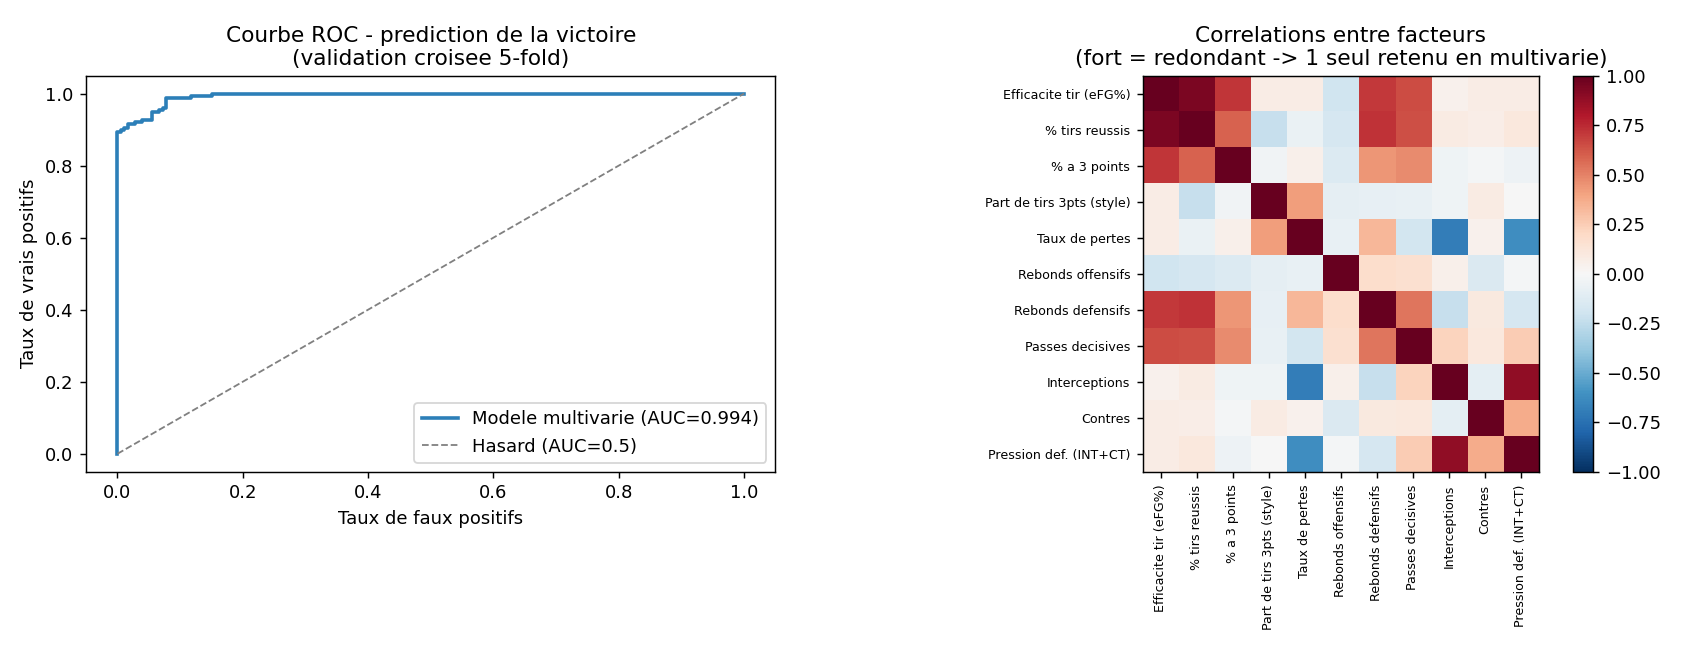

In [2]:
from IPython.display import Image
Image(filename=str(R / 'roc_correlations.png'))

## Predire avant le match

- L'ELO pronostique 68 % des matchs. Le favori perd environ une fois sur trois (32 %).
- Le classement final se predit des la mi-saison, a moins d'un rang d'erreur.
- On predit le vainqueur a environ 70 % et l'ecart de score a plus ou moins 10 points.

L'ELO fait le gros du travail, la forme recente ajoute un vrai plus, le reste (derby, historique direct) est marginal. Au-dela, l'alea du basket plafonne ce qu'on peut predire.

## Decouvertes complementaires sur les joueuses et les equipes

- La taille du cinq de depart compte plus que sa stabilite. L'equipe qui aligne plus de titulaires d'au moins 1,85 m que l'adversaire gagne environ deux fois sur trois (de 32 % a 68 % selon l'avantage).
- Le championnat valorise l'experience. La performance culmine vers 28 a 29 ans, et les effectifs se renouvellent a 60 % chaque saison (Bourges garde le plus son effectif, Charleville le change le plus).
- Une pepite ressort : D. Malonga (Lyon, 19 ans), avec un rendement par minute dans le top 5 % de la ligue.
- Basket Landes gagne presque tout a domicile (95 %) mais peine en deplacement. Villeneuve et Bourges gagnent autant dehors que chez elles, ce qui distingue les vraies equipes de tete.

## Les idees testees qui n'ont rien donne

Les resultats negatifs comptent autant que les positifs. On les a verifies, pas devines.

- Le style de jeu ne predit pas la victoire. Ajouter le style a l'ELO degrade meme la prediction. Seul le niveau compte.
- Le cinq de depart comme levier : ni la stabilite du cinq ni la dependance aux titulaires ne font gagner (AUC proche de 0,50).
- Le plus/minus individuel ne sert pas au recrutement. 64 % de sa variance vient de la force de l'equipe, pas de la joueuse.
- Les paris ne sont pas rentables. Environ 70 % de bons pronostics, mais le bookmaker garde l'avantage.
- Predire les playoffs : infaisable ici, car la phase finale n'a pas d'ELO avant match et les saisons disponibles ne se recouvrent qu'a moitie.
- Deux intuitions courantes tombent : les joueuses etrangeres ne jouent pas moins collectif, et les equipes dependantes d'une star ne sont pas plus imprevisibles (cette dependance est juste un marqueur de faiblesse).

## Pour aller plus loin

- 01 facteurs de victoire : classement, significativite, sources de points, starters.
- 02 exploratoire : forces par equipe, betes noires, pronostic ELO, avantage du terrain, panorama joueuses.
- 03 styles : pourquoi le style ne predit pas la victoire.
- 04 typologie des joueuses : axes et archetypes (PCA, clustering).
- 05 prediction : vainqueur, ecart, classement.
- 06 paris : walk-forward et rentabilite.